In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal

In [3]:
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("PROCESSED_DIR:", PROCESSED_DIR)

PROCESSED_DIR: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/data/processed


In [4]:
SEGMENTS = ["pre_meditation", "main_meditation", "recovery"]

# Main analysis set: EmotiBit_5 excluded
VALID_EMOTIBIT_IDS = [
    "EmotiBit_1",
    "EmotiBit_2",
    "EmotiBit_3",
    "EmotiBit_4",
    "EmotiBit_6",
    "EmotiBit_7",
]

EXCLUDED_EMOTIBIT_IDS = ["EmotiBit_5"]

# Conservative physiology settings
MIN_HR_BPM = 40
MAX_HR_BPM = 120

MIN_IBI_SEC = 60.0 / MAX_HR_BPM   # 0.5 s
MAX_IBI_SEC = 60.0 / MIN_HR_BPM   # 1.5 s

# Peak detection settings
MIN_PEAK_DISTANCE_SEC = 0.45   # slightly below 133 bpm ceiling, conservative
PROMINENCE_FACTOR = 0.35       # multiplied by signal std
HEIGHT_FACTOR = 0.00           # optional lower bound on height after filtering

In [5]:
def load_prepared_csv(emotibit_id, segment):
    path = PROCESSED_DIR / f"{emotibit_id}_{segment}_prepared.csv"
    if not path.exists():
        return None, path
    return pd.read_csv(path), path


def estimate_fs_from_timestamps(timestamps):
    timestamps = np.asarray(timestamps, dtype=float)
    if len(timestamps) < 2:
        return np.nan
    diffs = np.diff(timestamps)
    diffs = diffs[np.isfinite(diffs)]
    diffs = diffs[diffs > 0]
    if len(diffs) == 0:
        return np.nan
    return 1.0 / np.median(diffs)


def detect_ppg_peaks(filtered_signal, fs):
    """
    Peak detection on prepared filtered PPG.
    Returns peak indices and detection metadata.
    """
    x = np.asarray(filtered_signal, dtype=float)

    if len(x) < 3 or not np.isfinite(fs):
        return np.array([], dtype=int), {
            "prominence_used": np.nan,
            "distance_samples_used": np.nan,
            "height_used": np.nan,
        }

    x_std = np.nanstd(x)
    prominence = max(PROMINENCE_FACTOR * x_std, 1e-6)
    distance_samples = max(1, int(round(MIN_PEAK_DISTANCE_SEC * fs)))
    height = HEIGHT_FACTOR * x_std if np.isfinite(x_std) else None

    peaks, props = signal.find_peaks(
        x,
        distance=distance_samples,
        prominence=prominence,
        height=height
    )

    meta = {
        "prominence_used": prominence,
        "distance_samples_used": distance_samples,
        "height_used": height if height is not None else np.nan,
    }
    return peaks, meta


def compute_ibi_hr(peak_times):
    """
    From peak timestamps, compute:
    - IBI sequence in seconds
    - HR sequence in bpm
    Each IBI/HR is anchored to the second peak of the interval.
    """
    peak_times = np.asarray(peak_times, dtype=float)

    if len(peak_times) < 2:
        return pd.DataFrame(columns=["peak_time", "ibi_sec", "hr_bpm"])

    ibi = np.diff(peak_times)
    hr = 60.0 / ibi

    return pd.DataFrame({
        "peak_time": peak_times[1:],
        "ibi_sec": ibi,
        "hr_bpm": hr,
    })


def clean_ibi_hr(interval_df, min_ibi=0.5, max_ibi=1.5):
    """
    Flag and retain physiologically plausible intervals.
    """
    df = interval_df.copy()

    if len(df) == 0:
        df["ibi_valid"] = []
        df["hr_valid"] = []
        df["keep"] = []
        return df

    df["ibi_valid"] = df["ibi_sec"].between(min_ibi, max_ibi, inclusive="both")
    df["hr_valid"] = df["hr_bpm"].between(60.0 / max_ibi, 60.0 / min_ibi, inclusive="both")
    df["keep"] = df["ibi_valid"] & df["hr_valid"]

    return df


def summarize_peak_extraction(df_intervals, n_peaks_detected, segment_duration_sec):
    """
    Summary for QA.
    """
    if len(df_intervals) == 0:
        return {
            "n_peaks_detected": int(n_peaks_detected),
            "n_intervals_total": 0,
            "n_intervals_kept": 0,
            "fraction_intervals_kept": np.nan,
            "mean_hr_bpm_kept": np.nan,
            "std_hr_bpm_kept": np.nan,
            "mean_ibi_sec_kept": np.nan,
            "segment_duration_sec": float(segment_duration_sec),
            "detected_peak_rate_per_min": float(n_peaks_detected / (segment_duration_sec / 60.0)) if segment_duration_sec > 0 else np.nan,
        }

    kept = df_intervals[df_intervals["keep"]].copy()

    return {
        "n_peaks_detected": int(n_peaks_detected),
        "n_intervals_total": int(len(df_intervals)),
        "n_intervals_kept": int(len(kept)),
        "fraction_intervals_kept": float(len(kept) / len(df_intervals)) if len(df_intervals) > 0 else np.nan,
        "mean_hr_bpm_kept": float(kept["hr_bpm"].mean()) if len(kept) > 0 else np.nan,
        "std_hr_bpm_kept": float(kept["hr_bpm"].std()) if len(kept) > 1 else np.nan,
        "mean_ibi_sec_kept": float(kept["ibi_sec"].mean()) if len(kept) > 0 else np.nan,
        "segment_duration_sec": float(segment_duration_sec),
        "detected_peak_rate_per_min": float(n_peaks_detected / (segment_duration_sec / 60.0)) if segment_duration_sec > 0 else np.nan,
    }

In [6]:
print("Included in main extraction:", VALID_EMOTIBIT_IDS)
print("Excluded from main extraction:", EXCLUDED_EMOTIBIT_IDS)

Included in main extraction: ['EmotiBit_1', 'EmotiBit_2', 'EmotiBit_3', 'EmotiBit_4', 'EmotiBit_6', 'EmotiBit_7']
Excluded from main extraction: ['EmotiBit_5']


In [7]:
summary_rows = []

for emotibit_id in VALID_EMOTIBIT_IDS:
    for segment_name in SEGMENTS:
        df, path = load_prepared_csv(emotibit_id, segment_name)

        if df is None:
            print("Missing:", path)
            continue

        timestamps = df["timestamp"].values.astype(float)
        time_rel = df["time_from_segment_start_sec"].values.astype(float)
        filtered = df["selected_channel_filtered"].values.astype(float)
        selected_channel = df["selected_channel_name"].iloc[0]

        fs = estimate_fs_from_timestamps(timestamps)
        if not np.isfinite(fs):
            print(f"Could not estimate fs for {emotibit_id} {segment_name}")
            continue

        peak_idx, detect_meta = detect_ppg_peaks(filtered, fs)

        peak_df = pd.DataFrame({
            "peak_index": peak_idx,
            "peak_time": timestamps[peak_idx] if len(peak_idx) > 0 else [],
            "peak_time_from_segment_start_sec": time_rel[peak_idx] if len(peak_idx) > 0 else [],
            "peak_amplitude_filtered": filtered[peak_idx] if len(peak_idx) > 0 else [],
            "emotibit_id": emotibit_id,
            "segment": segment_name,
            "selected_channel": selected_channel,
        })

        peak_out_path = PROCESSED_DIR / f"{emotibit_id}_{segment_name}_peaks.csv"
        peak_df.to_csv(peak_out_path, index=False)

        interval_df = compute_ibi_hr(peak_df["peak_time"].values if len(peak_df) > 0 else np.array([]))
        interval_df["peak_time_from_segment_start_sec"] = (
            interval_df["peak_time"] - timestamps[0] if len(interval_df) > 0 else []
        )
        interval_df["emotibit_id"] = emotibit_id
        interval_df["segment"] = segment_name
        interval_df["selected_channel"] = selected_channel

        interval_df = clean_ibi_hr(
            interval_df,
            min_ibi=MIN_IBI_SEC,
            max_ibi=MAX_IBI_SEC
        )

        intervals_out_path = PROCESSED_DIR / f"{emotibit_id}_{segment_name}_ibi_hr.csv"
        interval_df.to_csv(intervals_out_path, index=False)

        segment_duration_sec = float(timestamps[-1] - timestamps[0]) if len(timestamps) > 1 else np.nan
        summary = summarize_peak_extraction(interval_df, len(peak_df), segment_duration_sec)

        summary_rows.append({
            "emotibit_id": emotibit_id,
            "segment": segment_name,
            "selected_channel": selected_channel,
            "fs_estimated": fs,
            "prominence_used": detect_meta["prominence_used"],
            "distance_samples_used": detect_meta["distance_samples_used"],
            "height_used": detect_meta["height_used"],
            "peaks_csv": peak_out_path.name,
            "ibi_hr_csv": intervals_out_path.name,
            **summary,
        })

        print("Saved:", peak_out_path)
        print("Saved:", intervals_out_path)

peak_hr_summary = pd.DataFrame(summary_rows).sort_values(
    ["emotibit_id", "segment"]
).reset_index(drop=True)

display(peak_hr_summary)

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/data/processed/EmotiBit_1_pre_meditation_peaks.csv
Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/data/processed/EmotiBit_1_pre_meditation_ibi_hr.csv
Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/data/processed/EmotiBit_1_main_meditation_peaks.csv
Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/data/processed/EmotiBit_1_main_meditation_ibi_hr.csv
Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/data/processed/EmotiBit_1_recovery_peaks.csv
Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/data/processed/EmotiBit_1_recovery_ibi_hr.csv
Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/data/processed/EmotiBit_2_pre_meditation_peaks.csv
Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/data/processed/EmotiBit_2_pre_meditation_ibi_hr.csv
Saved: /Users/sabirthapa/Desktop/emotibit/medi

,emotibit_id,segment,selected_channel,fs_estimated,prominence_used,distance_samples_used,height_used,peaks_csv,ibi_hr_csv,n_peaks_detected,n_intervals_total,n_intervals_kept,fraction_intervals_kept,mean_hr_bpm_kept,std_hr_bpm_kept,mean_ibi_sec_kept,segment_duration_sec,detected_peak_rate_per_min
0,EmotiBit_1,main_meditation,PPG_1,99.496057,10.460984,45,0.0,EmotiBit_1_main_meditation_peaks.csv,EmotiBit_1_main_meditation_ibi_hr.csv,826,825,806,0.976970,67.206757,11.809803,0.916916,753.467046,65.775936
1,EmotiBit_1,pre_meditation,PPG_1,99.496057,7.921082,45,0.0,EmotiBit_1_pre_meditation_peaks.csv,EmotiBit_1_pre_meditation_ibi_hr.csv,270,269,267,0.992565,67.350185,7.901492,0.901848,244.100126,66.366209
2,EmotiBit_1,recovery,PPG_1,99.496057,7.125192,45,0.0,EmotiBit_1_recovery_peaks.csv,EmotiBit_1_recovery_ibi_hr.csv,95,94,90,0.957447,66.889135,11.889959,0.919076,94.767575,60.147155
3,EmotiBit_2,main_meditation,PPG_1,100.020871,15.178313,45,0.0,EmotiBit_2_main_meditation_peaks.csv,EmotiBit_2_main_meditation_ibi_hr.csv,825,824,822,0.997573,66.055875,3.792846,0.911245,753.452750,65.697550
4,EmotiBit_2,pre_meditation,PPG_1,100.020871,5.107048,45,0.0,EmotiBit_2_pre_meditation_peaks.csv,EmotiBit_2_pre_meditation_ibi_hr.csv,268,267,267,1.000000,66.305244,5.577780,0.910896,244.099055,65.874897
5,EmotiBit_2,recovery,PPG_1,100.020871,21.003404,45,0.0,EmotiBit_2_recovery_peaks.csv,EmotiBit_2_recovery_ibi_hr.csv,105,104,104,1.000000,66.331064,2.490099,0.905869,94.770221,66.476578
6,EmotiBit_3,main_meditation,PPG_1,98.920147,9.009905,45,0.0,EmotiBit_3_main_meditation_peaks.csv,EmotiBit_3_main_meditation_ibi_hr.csv,850,849,844,0.994111,68.394253,8.030080,0.887846,753.466328,67.687165
7,EmotiBit_3,pre_meditation,PPG_1,98.920147,11.625517,45,0.0,EmotiBit_3_pre_meditation_peaks.csv,EmotiBit_3_pre_meditation_ibi_hr.csv,280,279,278,0.996416,69.815581,7.248162,0.867715,244.095877,68.825415
8,EmotiBit_3,recovery,PPG_1,98.920147,16.047339,45,0.0,EmotiBit_3_recovery_peaks.csv,EmotiBit_3_recovery_ibi_hr.csv,92,91,89,0.978022,68.767871,7.691010,0.883246,94.763304,58.250396
9,EmotiBit_4,main_meditation,PPG_2,99.070049,7.521122,45,0.0,EmotiBit_4_main_meditation_peaks.csv,EmotiBit_4_main_meditation_ibi_hr.csv,841,840,838,0.997619,67.575661,7.365245,0.897499,753.456781,66.971326


In [8]:
out_path = TABLES_DIR / "peak_detection_hr_summary.csv"
peak_hr_summary.to_csv(out_path, index=False)
print("Saved:", out_path)

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/peak_detection_hr_summary.csv


In [9]:
display(
    peak_hr_summary[
        [
            "emotibit_id", "segment", "selected_channel",
            "n_peaks_detected", "n_intervals_total", "n_intervals_kept",
            "fraction_intervals_kept", "mean_hr_bpm_kept", "mean_ibi_sec_kept"
        ]
    ]
)

,emotibit_id,segment,selected_channel,n_peaks_detected,n_intervals_total,n_intervals_kept,fraction_intervals_kept,mean_hr_bpm_kept,mean_ibi_sec_kept
0,EmotiBit_1,main_meditation,PPG_1,826,825,806,0.976970,67.206757,0.916916
1,EmotiBit_1,pre_meditation,PPG_1,270,269,267,0.992565,67.350185,0.901848
2,EmotiBit_1,recovery,PPG_1,95,94,90,0.957447,66.889135,0.919076
3,EmotiBit_2,main_meditation,PPG_1,825,824,822,0.997573,66.055875,0.911245
4,EmotiBit_2,pre_meditation,PPG_1,268,267,267,1.000000,66.305244,0.910896
5,EmotiBit_2,recovery,PPG_1,105,104,104,1.000000,66.331064,0.905869
6,EmotiBit_3,main_meditation,PPG_1,850,849,844,0.994111,68.394253,0.887846
7,EmotiBit_3,pre_meditation,PPG_1,280,279,278,0.996416,69.815581,0.867715
8,EmotiBit_3,recovery,PPG_1,92,91,89,0.978022,68.767871,0.883246
9,EmotiBit_4,main_meditation,PPG_2,841,840,838,0.997619,67.575661,0.897499


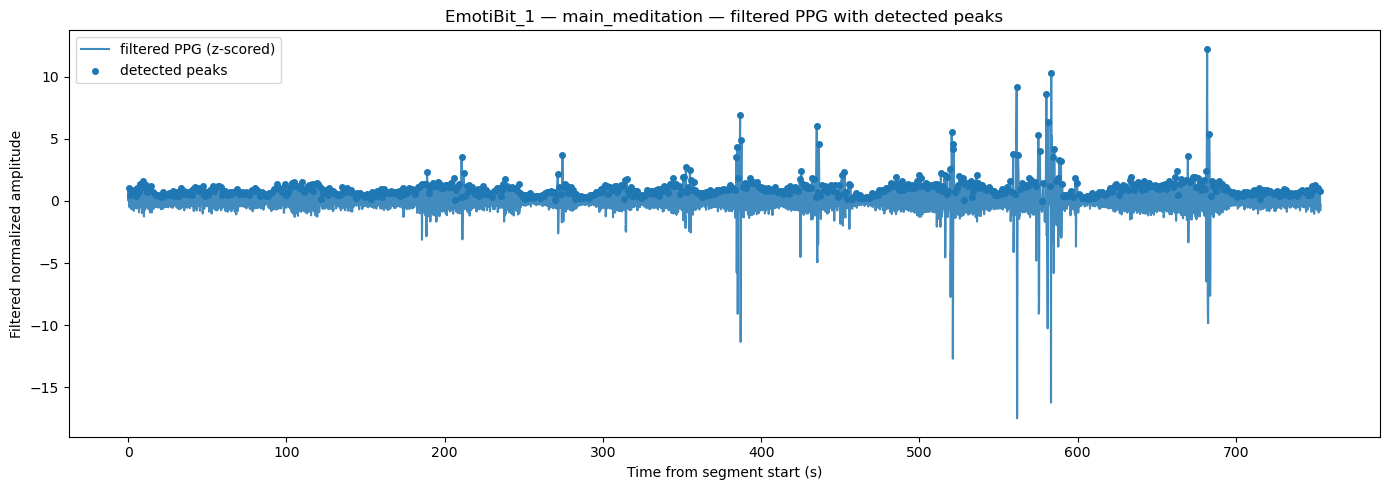

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_1_main_meditation_detected_peaks.png


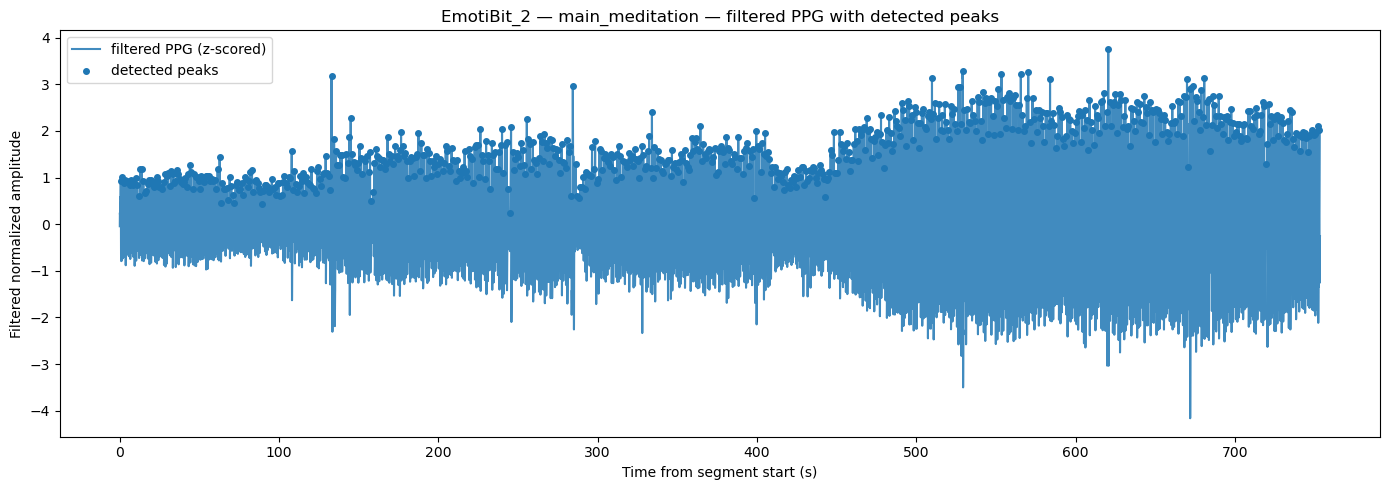

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_2_main_meditation_detected_peaks.png


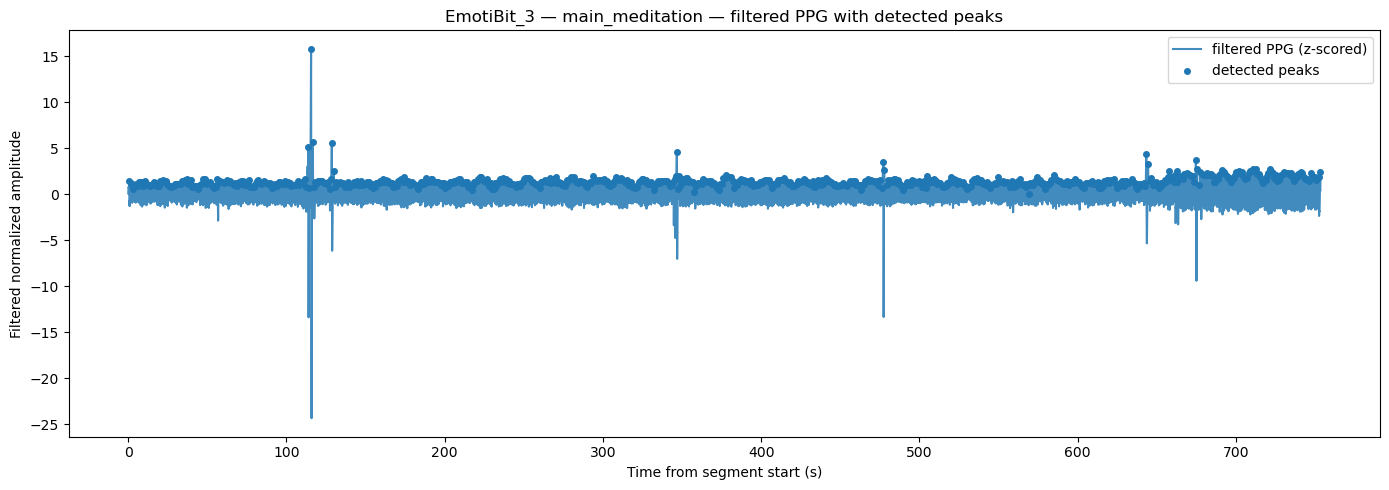

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_3_main_meditation_detected_peaks.png


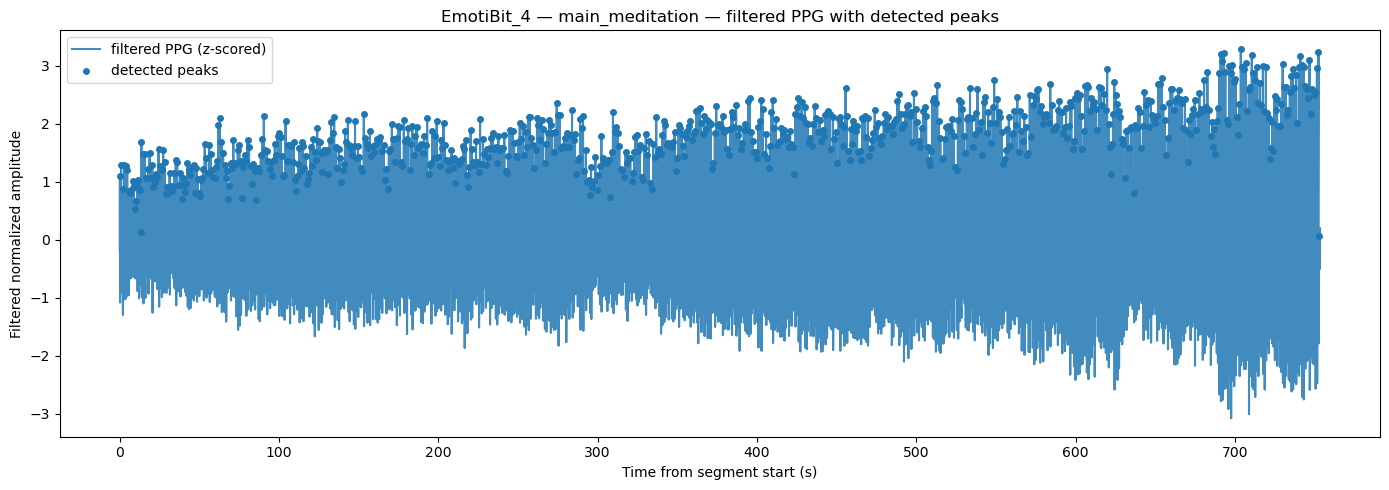

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_4_main_meditation_detected_peaks.png


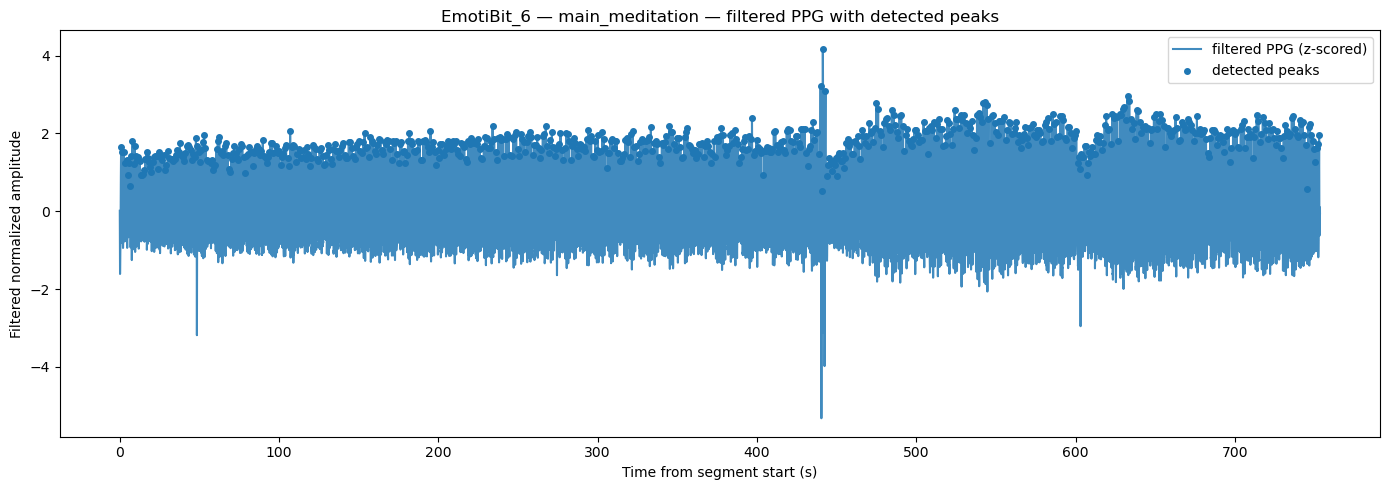

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_6_main_meditation_detected_peaks.png


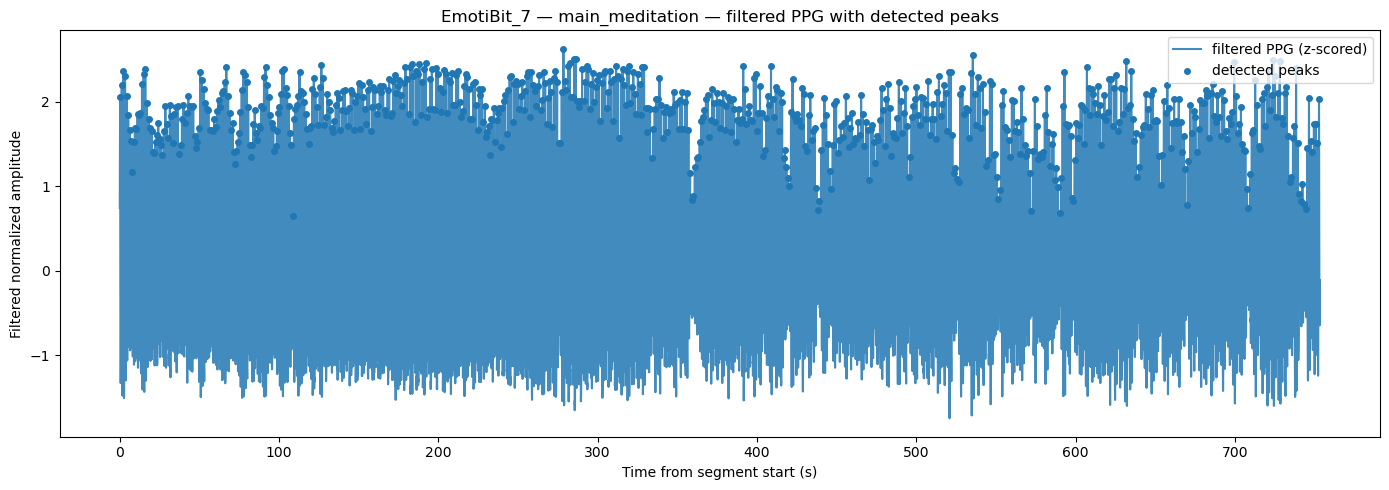

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_7_main_meditation_detected_peaks.png


In [10]:
for emotibit_id in VALID_EMOTIBIT_IDS:
    prepared_path = PROCESSED_DIR / f"{emotibit_id}_main_meditation_prepared.csv"
    peaks_path = PROCESSED_DIR / f"{emotibit_id}_main_meditation_peaks.csv"

    if not prepared_path.exists() or not peaks_path.exists():
        print("Missing files for:", emotibit_id)
        continue

    df = pd.read_csv(prepared_path)
    peaks_df = pd.read_csv(peaks_path)

    t = df["time_from_segment_start_sec"].values
    y = df["selected_channel_filtered_z"].values

    plt.figure(figsize=(14, 5))
    plt.plot(t, y, label="filtered PPG (z-scored)", alpha=0.85)

    if len(peaks_df) > 0:
        peak_times = peaks_df["peak_time_from_segment_start_sec"].values
        peak_indices = peaks_df["peak_index"].astype(int).values
        peak_vals = y[peak_indices]
        plt.scatter(peak_times, peak_vals, s=16, label="detected peaks")

    plt.title(f"{emotibit_id} — main_meditation — filtered PPG with detected peaks")
    plt.xlabel("Time from segment start (s)")
    plt.ylabel("Filtered normalized amplitude")
    plt.legend()
    plt.tight_layout()

    out_path = FIGURES_DIR / f"{emotibit_id}_main_meditation_detected_peaks.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

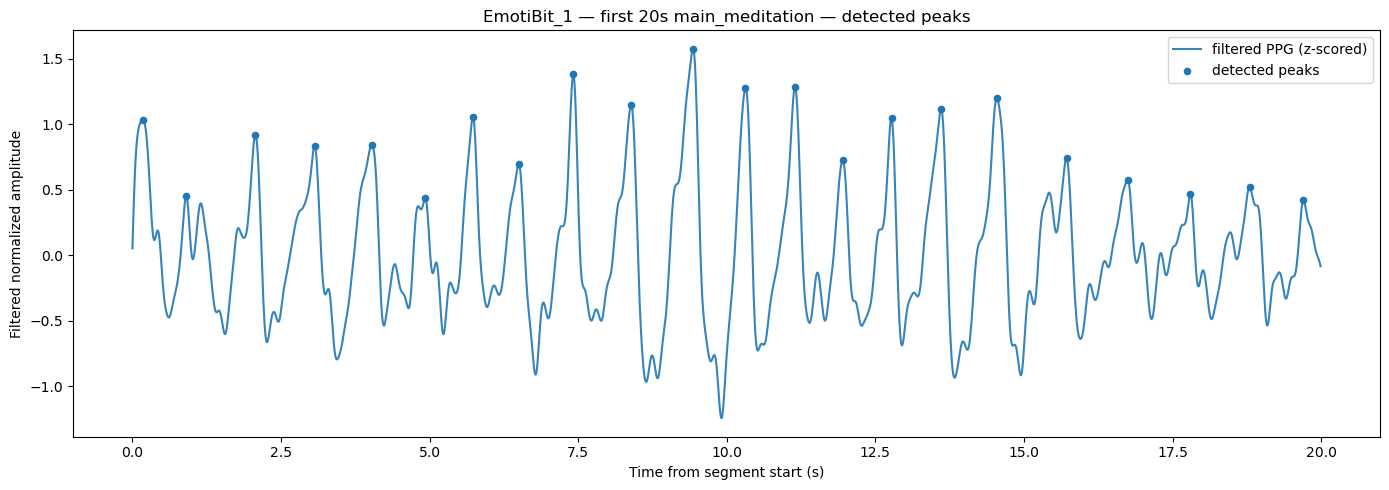

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_1_main_meditation_first20s_detected_peaks.png


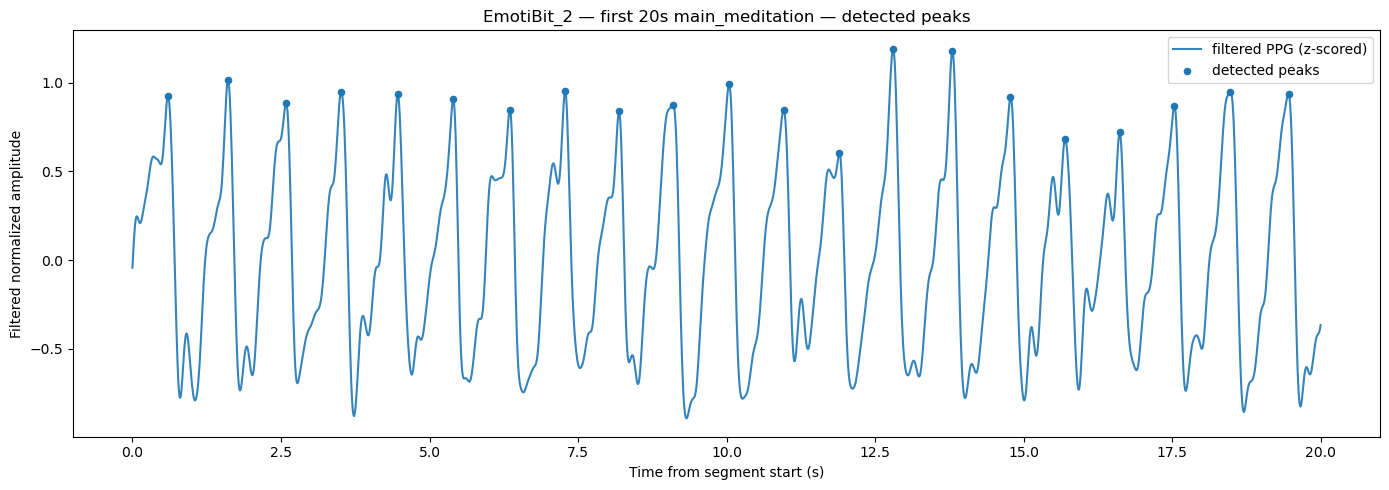

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_2_main_meditation_first20s_detected_peaks.png


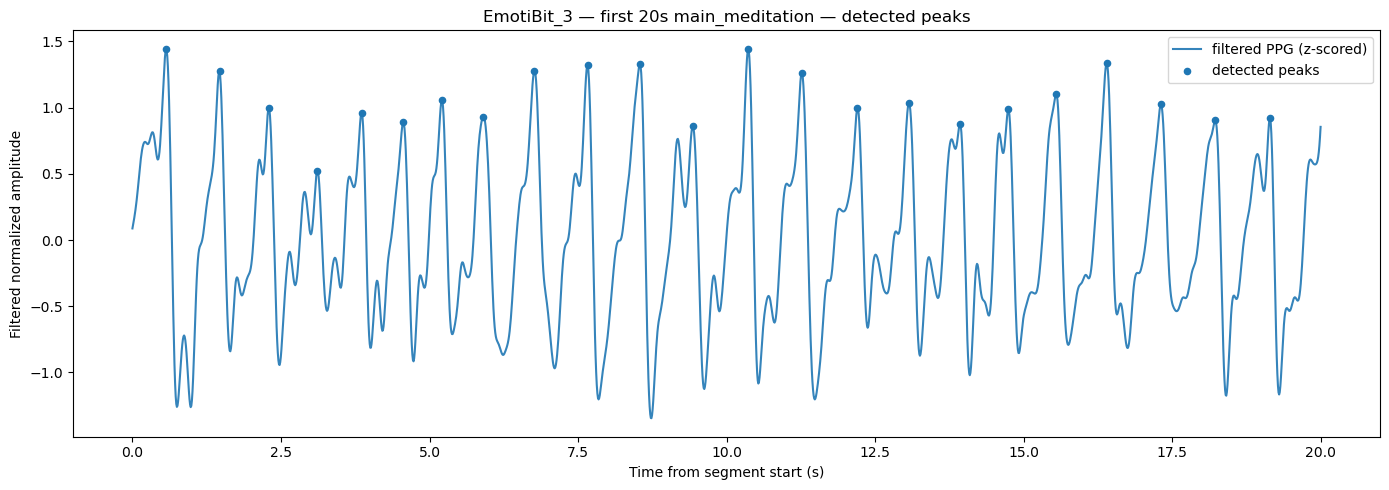

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_3_main_meditation_first20s_detected_peaks.png


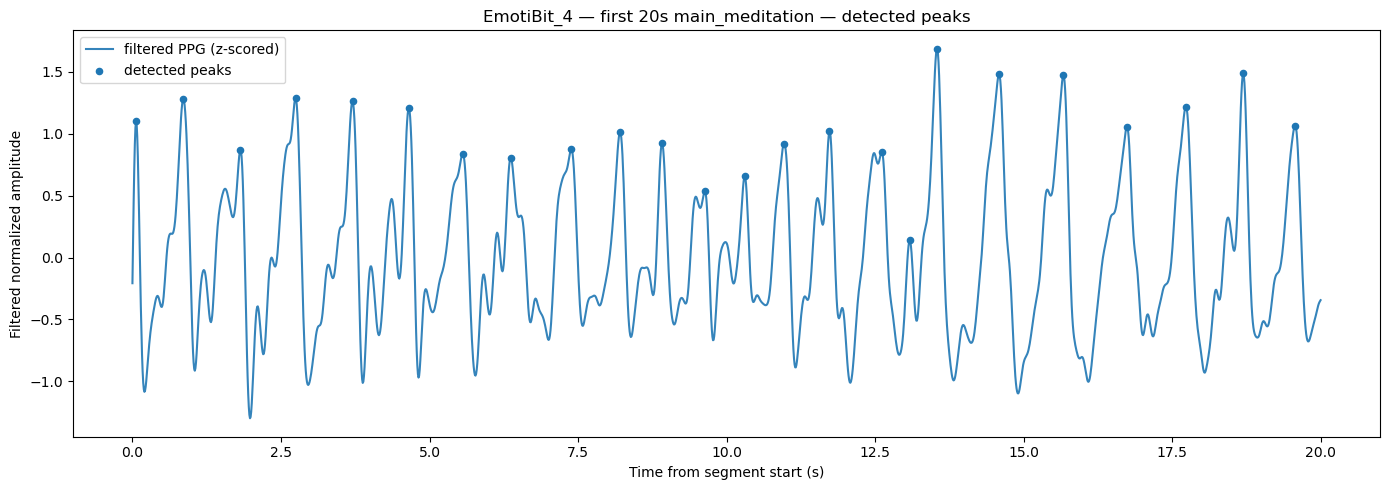

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_4_main_meditation_first20s_detected_peaks.png


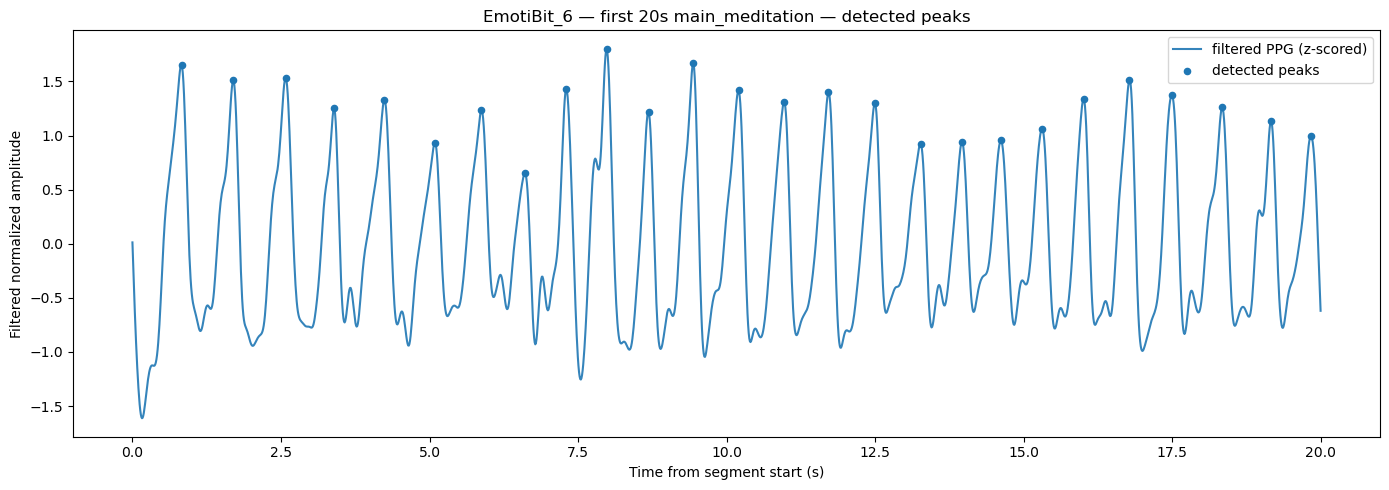

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_6_main_meditation_first20s_detected_peaks.png


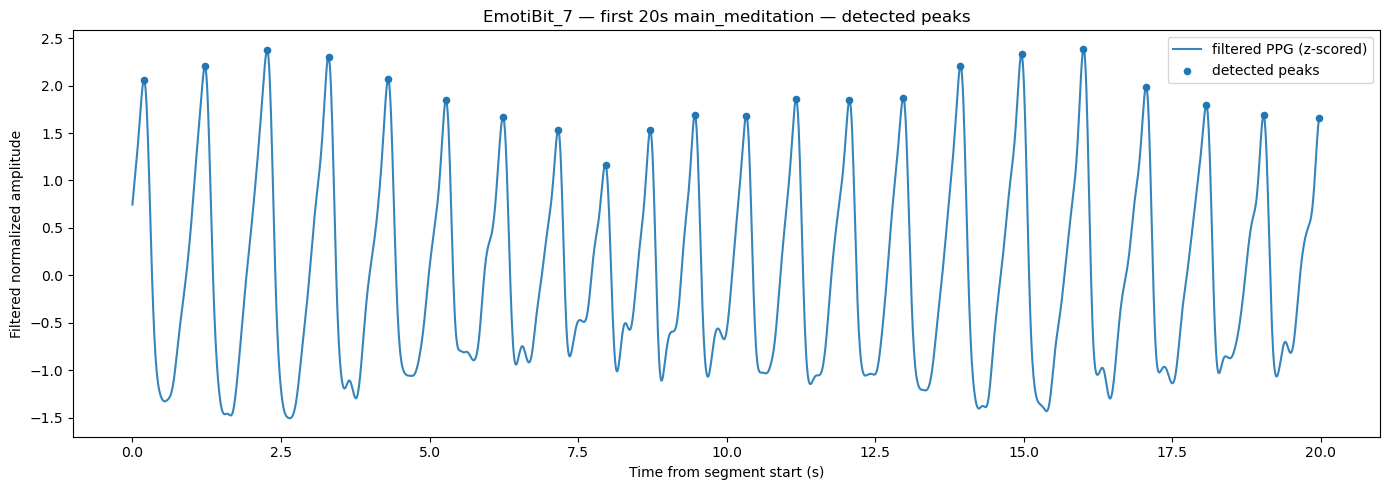

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_7_main_meditation_first20s_detected_peaks.png


In [11]:
for emotibit_id in VALID_EMOTIBIT_IDS:
    prepared_path = PROCESSED_DIR / f"{emotibit_id}_main_meditation_prepared.csv"
    peaks_path = PROCESSED_DIR / f"{emotibit_id}_main_meditation_peaks.csv"

    if not prepared_path.exists() or not peaks_path.exists():
        continue

    df = pd.read_csv(prepared_path)
    peaks_df = pd.read_csv(peaks_path)

    zoom_df = df[df["time_from_segment_start_sec"] <= 20].copy()

    if len(zoom_df) == 0:
        continue

    t = zoom_df["time_from_segment_start_sec"].values
    y = zoom_df["selected_channel_filtered_z"].values

    plt.figure(figsize=(14, 5))
    plt.plot(t, y, label="filtered PPG (z-scored)", alpha=0.9)

    if len(peaks_df) > 0:
        zoom_peaks = peaks_df[
            peaks_df["peak_time_from_segment_start_sec"] <= 20
        ].copy()

        if len(zoom_peaks) > 0:
            peak_times = zoom_peaks["peak_time_from_segment_start_sec"].values
            peak_indices = zoom_peaks["peak_index"].astype(int).values
            peak_vals = df["selected_channel_filtered_z"].values[peak_indices]
            plt.scatter(peak_times, peak_vals, s=20, label="detected peaks")

    plt.title(f"{emotibit_id} — first 20s main_meditation — detected peaks")
    plt.xlabel("Time from segment start (s)")
    plt.ylabel("Filtered normalized amplitude")
    plt.legend()
    plt.tight_layout()

    out_path = FIGURES_DIR / f"{emotibit_id}_main_meditation_first20s_detected_peaks.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

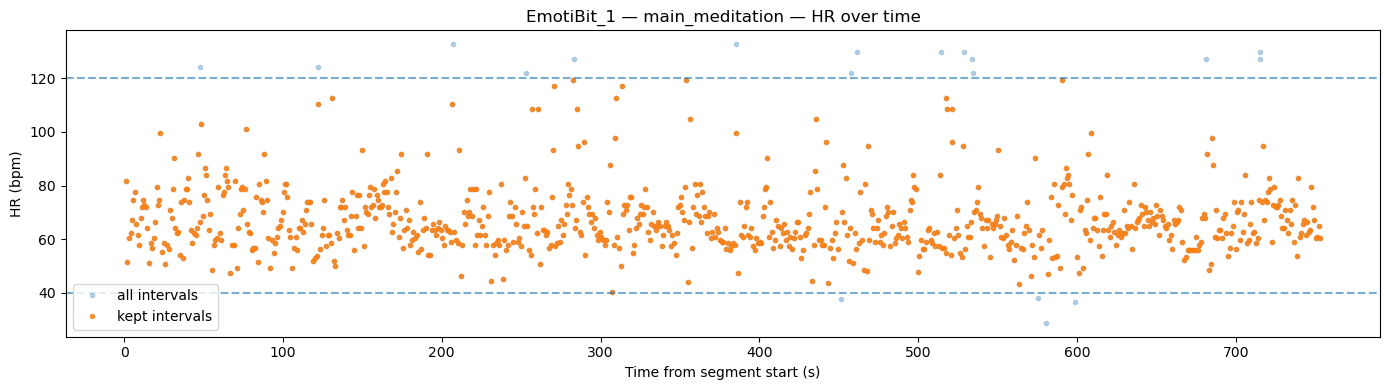

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_1_main_meditation_hr_over_time.png


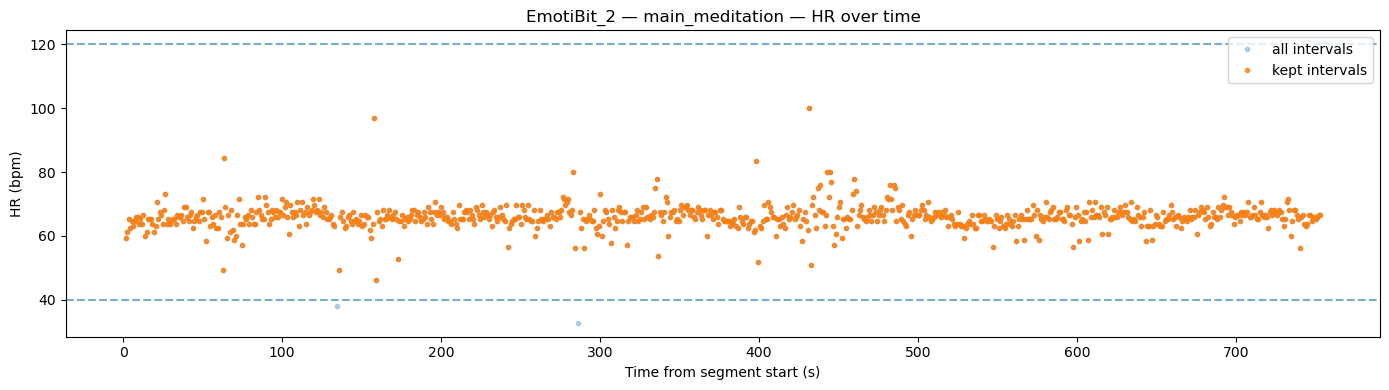

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_2_main_meditation_hr_over_time.png


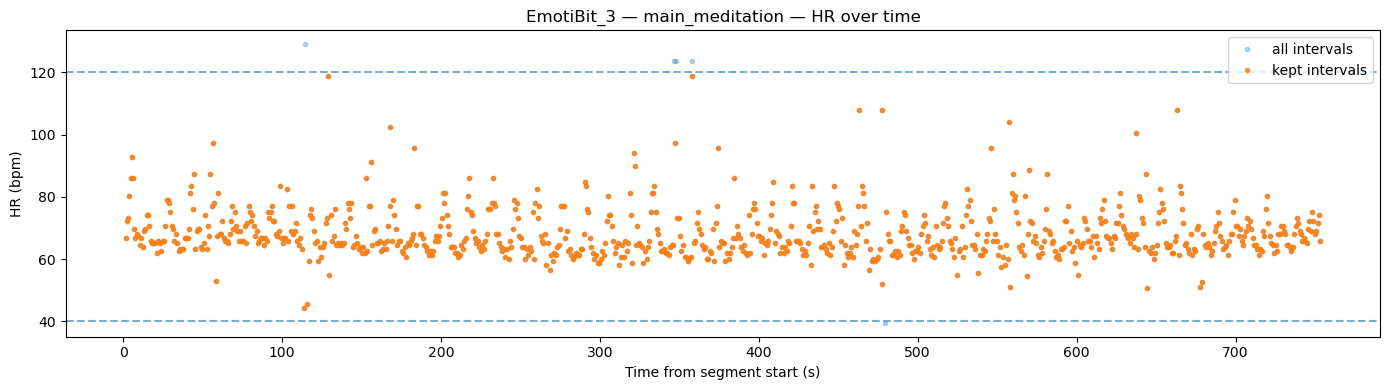

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_3_main_meditation_hr_over_time.png


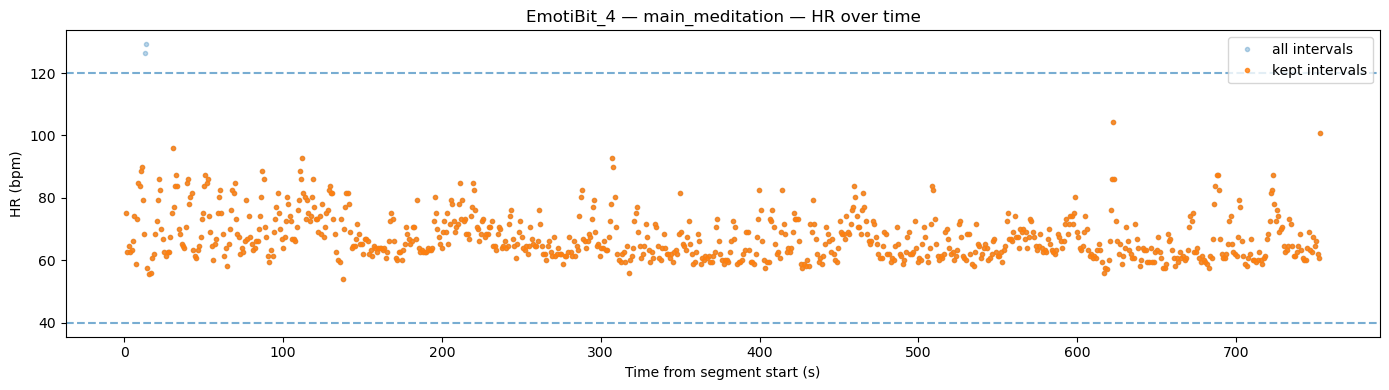

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_4_main_meditation_hr_over_time.png


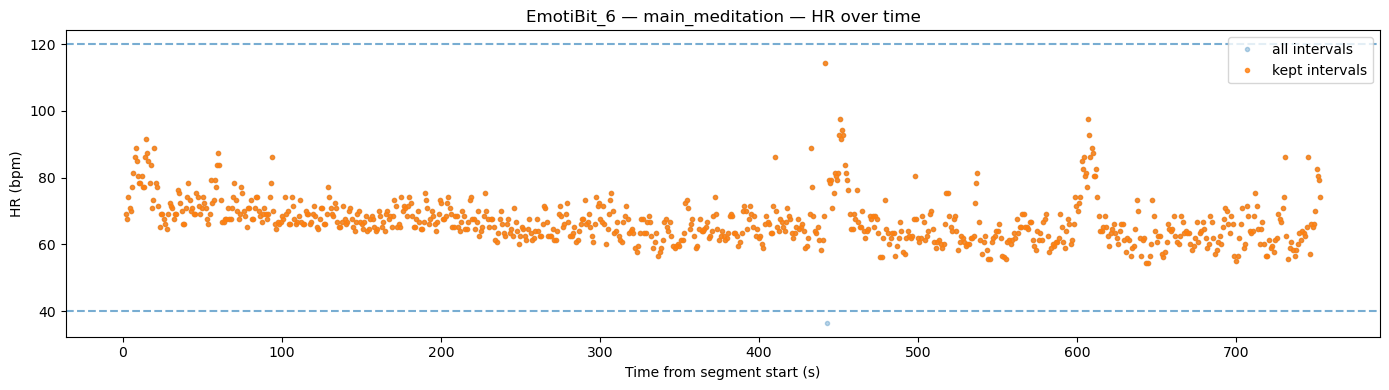

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_6_main_meditation_hr_over_time.png


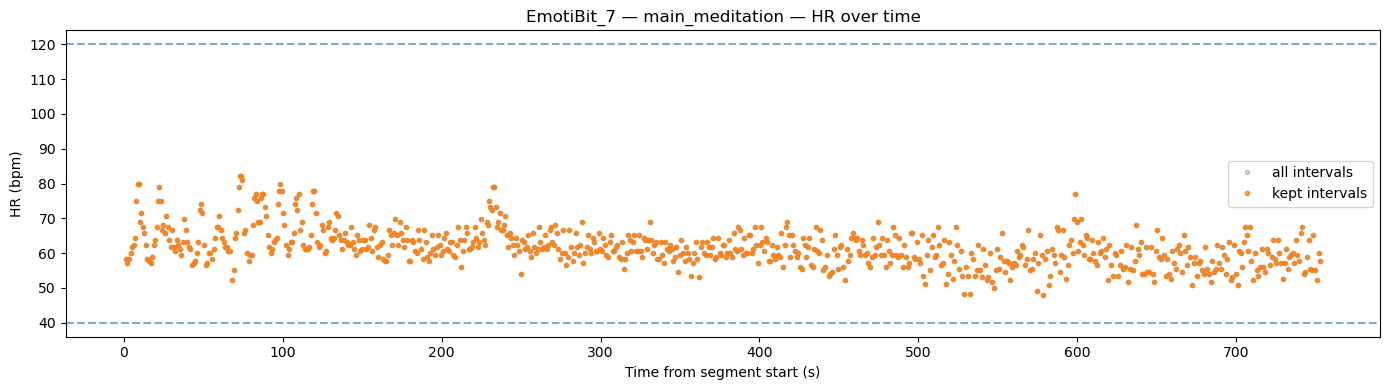

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_7_main_meditation_hr_over_time.png


In [12]:
for emotibit_id in VALID_EMOTIBIT_IDS:
    ibi_hr_path = PROCESSED_DIR / f"{emotibit_id}_main_meditation_ibi_hr.csv"
    if not ibi_hr_path.exists():
        continue

    df = pd.read_csv(ibi_hr_path)
    if len(df) == 0:
        print("No HR intervals for:", emotibit_id)
        continue

    kept = df[df["keep"]].copy()

    plt.figure(figsize=(14, 4))
    plt.plot(df["peak_time_from_segment_start_sec"], df["hr_bpm"], ".", alpha=0.3, label="all intervals")
    if len(kept) > 0:
        plt.plot(kept["peak_time_from_segment_start_sec"], kept["hr_bpm"], ".", alpha=0.8, label="kept intervals")

    plt.axhline(MIN_HR_BPM, linestyle="--", alpha=0.6)
    plt.axhline(MAX_HR_BPM, linestyle="--", alpha=0.6)

    plt.title(f"{emotibit_id} — main_meditation — HR over time")
    plt.xlabel("Time from segment start (s)")
    plt.ylabel("HR (bpm)")
    plt.legend()
    plt.tight_layout()

    out_path = FIGURES_DIR / f"{emotibit_id}_main_meditation_hr_over_time.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

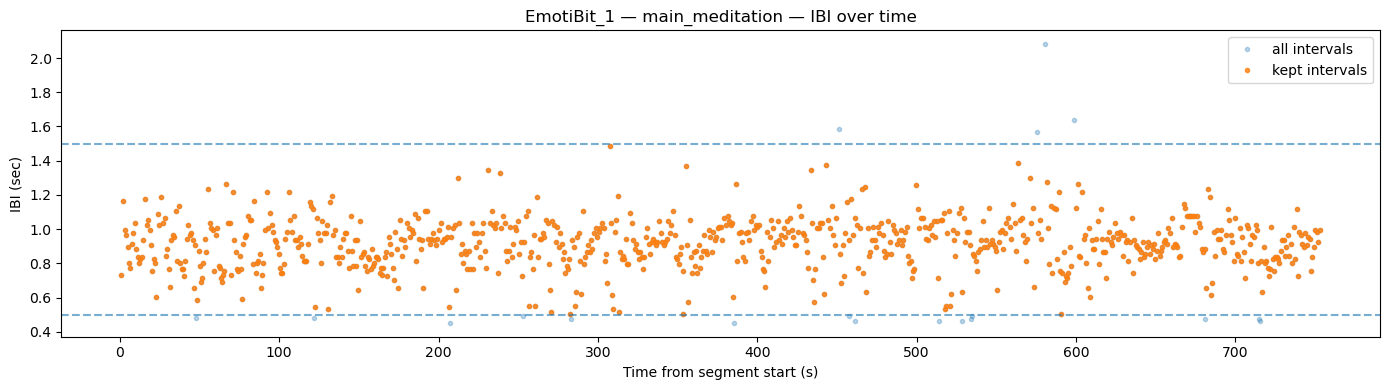

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_1_main_meditation_ibi_over_time.png


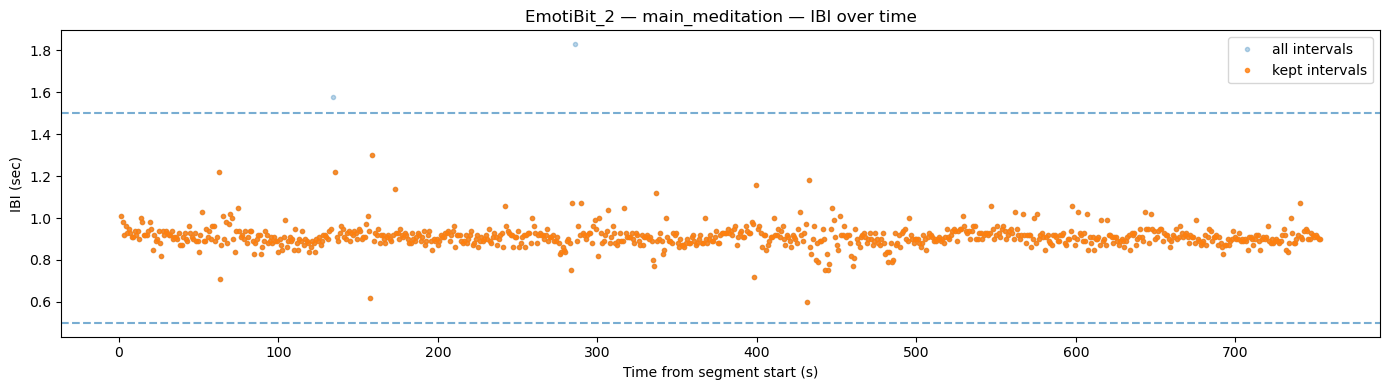

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_2_main_meditation_ibi_over_time.png


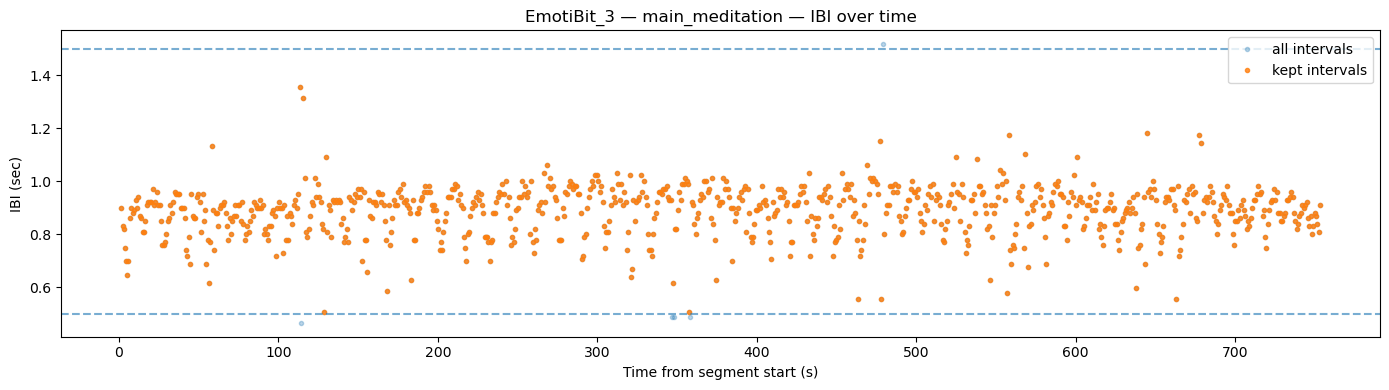

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_3_main_meditation_ibi_over_time.png


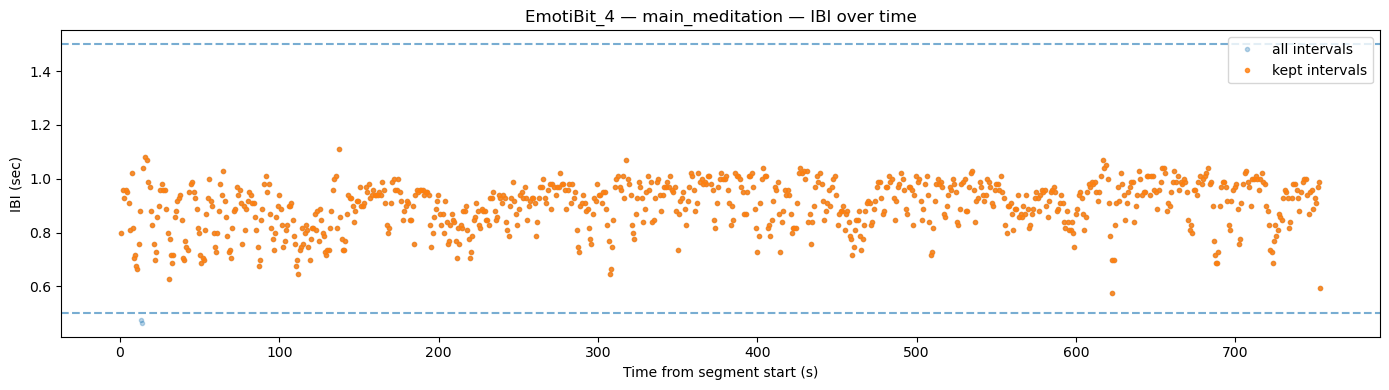

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_4_main_meditation_ibi_over_time.png


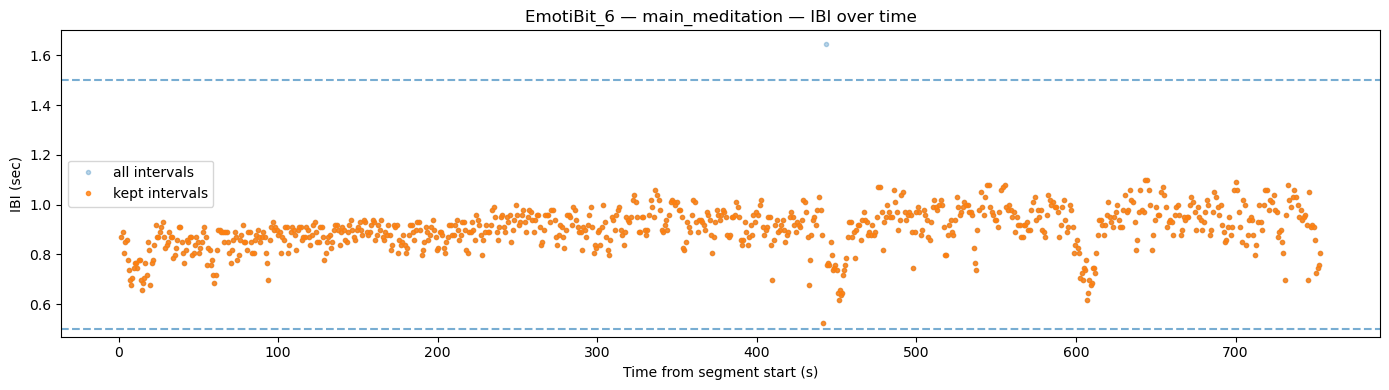

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_6_main_meditation_ibi_over_time.png


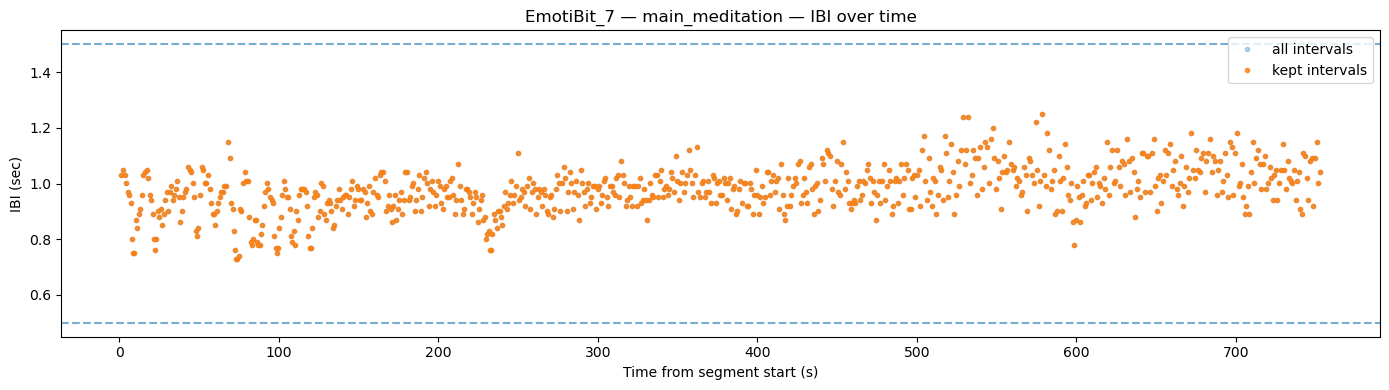

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/figures/EmotiBit_7_main_meditation_ibi_over_time.png


In [13]:
for emotibit_id in VALID_EMOTIBIT_IDS:
    ibi_hr_path = PROCESSED_DIR / f"{emotibit_id}_main_meditation_ibi_hr.csv"
    if not ibi_hr_path.exists():
        continue

    df = pd.read_csv(ibi_hr_path)
    if len(df) == 0:
        continue

    kept = df[df["keep"]].copy()

    plt.figure(figsize=(14, 4))
    plt.plot(df["peak_time_from_segment_start_sec"], df["ibi_sec"], ".", alpha=0.3, label="all intervals")
    if len(kept) > 0:
        plt.plot(kept["peak_time_from_segment_start_sec"], kept["ibi_sec"], ".", alpha=0.8, label="kept intervals")

    plt.axhline(MIN_IBI_SEC, linestyle="--", alpha=0.6)
    plt.axhline(MAX_IBI_SEC, linestyle="--", alpha=0.6)

    plt.title(f"{emotibit_id} — main_meditation — IBI over time")
    plt.xlabel("Time from segment start (s)")
    plt.ylabel("IBI (sec)")
    plt.legend()
    plt.tight_layout()

    out_path = FIGURES_DIR / f"{emotibit_id}_main_meditation_ibi_over_time.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

In [14]:
clean_hr_rows = []

for emotibit_id in VALID_EMOTIBIT_IDS:
    for segment_name in SEGMENTS:
        ibi_hr_path = PROCESSED_DIR / f"{emotibit_id}_{segment_name}_ibi_hr.csv"
        if not ibi_hr_path.exists():
            continue

        df = pd.read_csv(ibi_hr_path)
        if len(df) == 0:
            continue

        kept = df[df["keep"]].copy()

        clean_df = kept[
            ["peak_time", "peak_time_from_segment_start_sec", "ibi_sec", "hr_bpm"]
        ].copy()
        clean_df["emotibit_id"] = emotibit_id
        clean_df["segment"] = segment_name

        out_path = PROCESSED_DIR / f"{emotibit_id}_{segment_name}_hr_clean.csv"
        clean_df.to_csv(out_path, index=False)

        clean_hr_rows.append({
            "emotibit_id": emotibit_id,
            "segment": segment_name,
            "n_clean_rows": len(clean_df),
            "output_csv": out_path.name,
        })

        print("Saved:", out_path)

clean_hr_summary = pd.DataFrame(clean_hr_rows).sort_values(
    ["emotibit_id", "segment"]
).reset_index(drop=True)

display(clean_hr_summary)

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/data/processed/EmotiBit_1_pre_meditation_hr_clean.csv
Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/data/processed/EmotiBit_1_main_meditation_hr_clean.csv
Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/data/processed/EmotiBit_1_recovery_hr_clean.csv
Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/data/processed/EmotiBit_2_pre_meditation_hr_clean.csv
Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/data/processed/EmotiBit_2_main_meditation_hr_clean.csv
Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/data/processed/EmotiBit_2_recovery_hr_clean.csv
Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/data/processed/EmotiBit_3_pre_meditation_hr_clean.csv
Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/data/processed/EmotiBit_3_main_meditation_hr_clean.csv
Saved: /Users/sabirthapa/

,emotibit_id,segment,n_clean_rows,output_csv
0,EmotiBit_1,main_meditation,806,EmotiBit_1_main_meditation_hr_clean.csv
1,EmotiBit_1,pre_meditation,267,EmotiBit_1_pre_meditation_hr_clean.csv
2,EmotiBit_1,recovery,90,EmotiBit_1_recovery_hr_clean.csv
3,EmotiBit_2,main_meditation,822,EmotiBit_2_main_meditation_hr_clean.csv
4,EmotiBit_2,pre_meditation,267,EmotiBit_2_pre_meditation_hr_clean.csv
5,EmotiBit_2,recovery,104,EmotiBit_2_recovery_hr_clean.csv
6,EmotiBit_3,main_meditation,844,EmotiBit_3_main_meditation_hr_clean.csv
7,EmotiBit_3,pre_meditation,278,EmotiBit_3_pre_meditation_hr_clean.csv
8,EmotiBit_3,recovery,89,EmotiBit_3_recovery_hr_clean.csv
9,EmotiBit_4,main_meditation,838,EmotiBit_4_main_meditation_hr_clean.csv


In [15]:
out_path = TABLES_DIR / "clean_hr_file_summary.csv"
clean_hr_summary.to_csv(out_path, index=False)
print("Saved:", out_path)

Saved: /Users/sabirthapa/Desktop/emotibit/meditation_group_synchrony/outputs/tables/clean_hr_file_summary.csv


In [16]:
quality_screen = peak_hr_summary.copy()

quality_screen["flag_low_keep_fraction"] = quality_screen["fraction_intervals_kept"] < 0.80
quality_screen["flag_low_peak_count"] = quality_screen["n_peaks_detected"] < 20
quality_screen["flag_hr_outside_expected_mean"] = ~quality_screen["mean_hr_bpm_kept"].between(45, 100, inclusive="both")

display(
    quality_screen[
        [
            "emotibit_id", "segment", "n_peaks_detected", "n_intervals_kept",
            "fraction_intervals_kept", "mean_hr_bpm_kept",
            "flag_low_keep_fraction", "flag_low_peak_count", "flag_hr_outside_expected_mean"
        ]
    ]
)

,emotibit_id,segment,n_peaks_detected,n_intervals_kept,fraction_intervals_kept,mean_hr_bpm_kept,flag_low_keep_fraction,flag_low_peak_count,flag_hr_outside_expected_mean
0,EmotiBit_1,main_meditation,826,806,0.976970,67.206757,False,False,False
1,EmotiBit_1,pre_meditation,270,267,0.992565,67.350185,False,False,False
2,EmotiBit_1,recovery,95,90,0.957447,66.889135,False,False,False
3,EmotiBit_2,main_meditation,825,822,0.997573,66.055875,False,False,False
4,EmotiBit_2,pre_meditation,268,267,1.000000,66.305244,False,False,False
5,EmotiBit_2,recovery,105,104,1.000000,66.331064,False,False,False
6,EmotiBit_3,main_meditation,850,844,0.994111,68.394253,False,False,False
7,EmotiBit_3,pre_meditation,280,278,0.996416,69.815581,False,False,False
8,EmotiBit_3,recovery,92,89,0.978022,68.767871,False,False,False
9,EmotiBit_4,main_meditation,841,838,0.997619,67.575661,False,False,False


In [17]:
print("=== PEAK DETECTION AND HR EXTRACTION SUMMARY ===")
print("Main analysis excluded: EmotiBit_5")
print("Generated:")
print("- peak files per segment")
print("- IBI/HR files per segment")
print("- cleaned HR-only files per segment")
print()
print("Next step:")
print("Build resampled/group-aligned HR time series for synchrony analysis")

=== PEAK DETECTION AND HR EXTRACTION SUMMARY ===
Main analysis excluded: EmotiBit_5
Generated:
- peak files per segment
- IBI/HR files per segment
- cleaned HR-only files per segment

Next step:
Build resampled/group-aligned HR time series for synchrony analysis
